In [18]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

In [5]:
f(3.0)

20.0

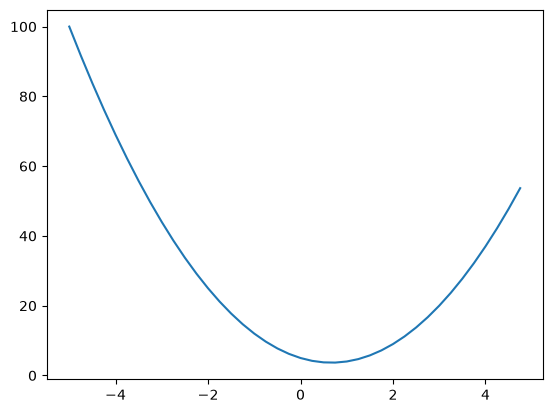

In [6]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [7]:
h = 0.00000001
x = 2/3
(f(x+h) - f(x))/h # rise over run

0.0

This is just a numerical approximation of the slope, because we have to make 'h' very very small to converge to the actual amount

At some point the slope is going to be 0 --> aim to reach (to minimize the loss function).

Value for this function --> previously looked up --> value of x = 2/3 the slope is 0. At this point if we nudge the input in the positive direction the function doesnt respond, and stays almost the same.

A different example for building expression graph and the gradients at each node wrt. its respective inputs.

In [8]:
h = 0.00000001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c

d1

c += h

d2 = a*b + c

print('d1', d1)
print('d2', d2)

print('slope', (d2-d1)/h)

d1 4.0
d2 4.000000010000001
slope 1.000000082740371


Neural Netowrks will be Massive Mathematical Expressions : 
when we move to neural networks we need some kind of data structure to hold these values and maintain expressions. Build out the Value object.

In [ ]:
class Value:
    def __init__(self, data, _children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0 
        # maintain the derivate of L wrt to that particular leaf node value ; 0 initially since we know that it does not affect the output.
        # i.e. change in this value does not affect the output.
        # _backward is a function that will be called when we backpropagate. --> implement the chain rule : we are going to chain the outputs gradient to the inputs gradient.
        self._backward =  lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"value(data = {self.data}, label = {self.label})"
    
    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        out = self + (-other)
        return out
    
    def __pow__(self, other): # x^k
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}', f'{self.data}**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward 
        return out
        
    
    def __truediv__(self, other):
        return self * (other ** -1)
    
    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def exp(self):
        x = self.data
        e = math.exp(x)
        out = Value(e, (self,), 'exp')

        def _backward():
            self.grad += e * out.grad
        out._backward = _backward
        return out


    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def relu(self):
        x = self.data
        r = x if x > 0 else 0
        out = Value(r, (self,), 'ReLU')

        def _backward():
            self.grad += (1 if x > 0 else 0) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

           


a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b ; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d*f ; L.label = 'L'
L # getting to the value of L is the forward pass. from a --> L 

#Stage 1 : Breakpoint
# Now what we are missing is the connective tissue of this expression graph.
# Inorder to keep this expression graph, we need to know what values and keep pointers about what values produce what other values.

#Stage 2 :  Run backpropagation. --> start from the end and work backwards calculating the gradient(derivative of that node wrt to L) along every intermediate node values.
# In a Neural Network setting, L - Loss function we would be very interested in finding the gradient of the loss function wrt to the weights and the biases.
# Interested in finding the derivative of the output wrt to some of these leaf nodes, which in a neural network setting are the weights and the biases and other leaf nodes can be the data itself.
# Not find the derivative of the output(Loss function) wrt to the weights and the biases and not the date since the data is fixed.
#Activation functions are something that squashes the output of a neuron to a certain range. Sigmoid, ReLU, Tanh, etc.


value(data = -8.0, label = L)

In [98]:
a = Value(2.0)
a+1
a * 2

3 * a

a.exp()
b = Value(4.0)
a/b
a - 2

value(data = 0.0, label = )

Add Graphviz for visualization. --> for expression graph visualization.

In [33]:
from graphviz import Digraph
from numpy import shape

def trace(root):
    # builds a set of all nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr = {'rankdir': 'LR'}) # LR - left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the grpah, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            #if this value is the result of some operation, draw a edge from the operation to the value
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        #draw an edge between the operator and the resulting value
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

we are going to do another example - complex :  backpropagate through a Neuron. eventually build out Neural nets : called MLP - Multi-Layer Perceptrons

A single Neuron : has inputs : X's (Axes) ; It also has synapes (W's - Weights) ; Synapse interacts with the input multiplicatively ---> Input to cell Body W.X (each of them are arrays xo,x1,x2... ; w0,w1,w2...) cell body : W*X + b(bias)

Then we take it(function -- W.X + b) --> through an activation fucntion : some sort of function that squashes the output into a particular range. #Activation functions are something that squashes the output of a neuron to a certain range. Sigmoid, ReLU, Tanh, etc.

Inputs as they come in -- get sqashed in between -1 to 1 in the y axis. ---> what comes out of the nueron is the out of the dot product (W.X + b) passed through the activation function

In [100]:
# Designing a Neuron  - > Inputs x1,x2

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#Weights - w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#Bias - b
b = Value(6.8813735870195432, label = 'b')
# x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b ; n.label = 'n' # (Cell Body) n is the output of the neuron - before passing through the activation function

o = n.tanh() ; o.label = 'o'



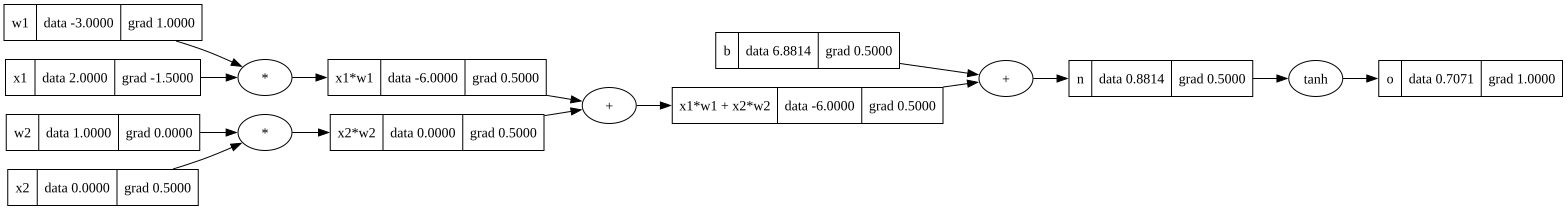

In [103]:
draw_dot(o)

In [102]:
o.backward()

As long as we know the derivative of tanh --> we will be able to backpropagate.

Derivative of Tanh --> do/do = 1 

do/dn = local derivative of Tanh = 1 - (tanhx)^2 : i.e. 1 - o^2

Do manual Back propagation for this Neuron. : Todo

If the weight that matters goes up then then output also will go up.

We can see here that out b = 2 * a, and the gradient db/da = 2, but instead it is just one, since the other (Value) a's grad is being over written, where in it is the same value and has to be accumulated.

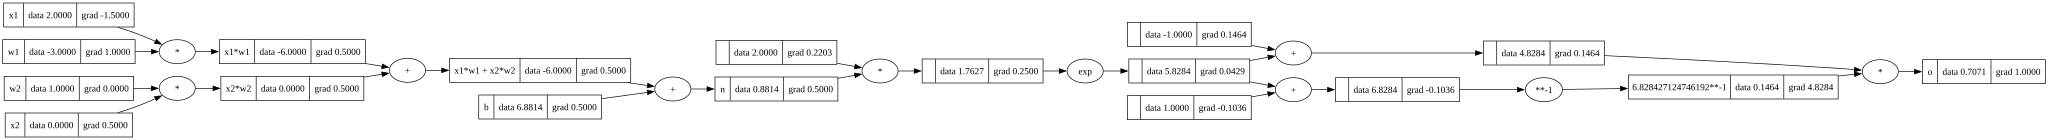

In [106]:
# Breaking Tanh into its components --> (e^2x - 1)/(e^2x + 1)
# Designing a Neuron  - > Inputs x1,x2

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#Weights - w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#Bias - b
b = Value(6.8813735870195432, label = 'b')
# x1w1 + x2w2 + b
x1w1 = x1*w1 ; x1w1.label = 'x1*w1'
x2w2 = x2*w2 ; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b ; n.label = 'n' # (Cell Body) n is the output of the neuron - before passing through the activation function

# o = (n.exp() - (-n).exp())/(n.exp() + (-n).exp())
e = (2*n).exp()
o = (e - 1)/(e + 1)
o.label = 'o'

o.backward()
draw_dot(o)

In [107]:
import torch

In [111]:
x1 = torch.Tensor([2.0]).double()        ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x1.grad', x1.grad.item())
print('x2.grad', x2.grad.item())
print('w1.grad', w1.grad.item())
print('w2.grad', w2.grad.item())
print('b.grad', b.grad.item())




0.7071066904050358
----
x1.grad -1.5000003851533106
x2.grad 0.5000001283844369
w1.grad 1.0000002567688737
w2.grad 0.0
b.grad 0.5000001283844369


Creating a Neuron class : Defining a single Neuron
I. Has a init function
1. Has weights for eah inputs (dimention of the input tensor)
2. Has a bias
II. Has a call fucntion : for doing n(x) : n = Neuron object and x = input tensor
1. To calculate W.X(dot product) + b --> (raw activation)
2. Pass it through the activation function (our choice - tanh)



In [221]:
import random


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1), label='w') for _ in range(nin)]
        self.b = Value(random.uniform(-1,1), label='b')
    
    def __call__(self,x):
        # x is a tensor of inputs
        # calculate the dot product between the weights and the inputs
        # add the bias
        # apply the activation function
        # return the output
        rawAct = self.b
        for wi, xi, in zip(self.w, x):
            rawAct += wi*xi
        rawAct.label = 'rawAct'
        out = rawAct.tanh()
        out.label = 'o'

        return out
    
    def parameters(self):
        return self.w + [self.b]


Next : Adding a Layer of Neurons - Hidden Layers
What is a Layer .? 
1. It has a number of Neurons, not connected to each other, but are all fully connected to the input Layer.
2. What this means is that, each of the neurons in this layer are evaluated independently.

I. Has an Init function : dimentionality of the input tensor, set of Neurons in the particular later. 
1. A list of Neurons
2. A call function which evaluated the raw Activation for each of the neurons ---> and passing it thought the activation function tanh for each of the neurons. n(x)

 

In [222]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
    
    



Designing an MLP:

In an MLP these layers just feed into each other.
1. no of inputs, nouts as a list (sizes of all the layers we want) in our MLP.
2. put nin and nouts together and iterate over all of them together -- > over consecutive pairs and create layer objects for them.
3. call function --> call them sequentially


In [223]:
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            # print(x)
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            ps = layer.parameters()
            params.extend(ps)
        return params

    

In [246]:
x = [2.0, 3.0, -4.0]
n = MLP(3,[4,4,1])
n(x)

value(data = 0.878565014856866, label = o)

Define sample data and loss function : Yout - Ypred


In [247]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]    
]

ys = [1.0, -1.0, -1.0, 1.0] #desired output


The Gradients on the input data are not useful to us since they are fixed and their values cannot be changed. Focusing only on the grad of weights and bias. and the grad of weights suggest the direction in which they have to be moved to acheive reduction in loss.


Gradient Descent - Updating parameter step 
think of the gradient as a vector pointing in the direction of increasing the loss, but we want to decrease it, so we update the value of the weights in the opposite direction to it gradient.

In [ ]:

# tuning the weights of the NN to be more accurate
# we need to find a single number that measures the total performance of the NN.
# we can do this by using a loss function.
# loss function : Yout - Ypred
# we can use the mean squared error as a loss function.
#Currently the loss is high --> we need to reduce the loss.

for k in range(100):
    #forward pass
    ypred = [n(x) for x in xs]

    loss = Value(0.0, label = 'loss')
    for ygt, yout in zip(ys, ypred):
        loss += ((yout - ygt)**2)
    
    #zero down the grad before doing backward pass --> resetting the grad to 0; so the actual backpropogation is not affected by the previous backpropogation.
    #Common bug : forgetting to zero down the grad before doing backward pass.
    for p in n.parameters():
        p.grad = 0.0

    #backward pass
    loss.backward()

    #update weights
    for p in n.parameters():
        p.data += -0.05 * p.grad
    
    print(k, loss.data)
    
 

0 2.495163368885507
1 0.2794067087958505
2 0.14061543766770143
3 0.1079774573231249
4 0.08883293788375528
5 0.0757146192932161
6 0.06603627655984332
7 0.05856311151302118
8 0.052605166723365446
9 0.04773901004890045
10 0.04368779631827081
11 0.04026192553437644
12 0.03732679412553417
13 0.03478403240123861
14 0.032560002776129505
15 0.030598449074175364
16 0.02885563517803398
17 0.027297036090848104
18 0.025895029432358996
19 0.024627250003082607
20 0.023475394649450233
21 0.02242433954716008
22 0.02146147839244925
23 0.02057621947024619
24 0.019759598748612932
25 0.019003978890225804
26 0.018302812695248492
27 0.017650455426311745
28 0.01704201461642336
29 0.0164732289033179
30 0.01594036954764974
31 0.015440159829333383
32 0.014969708646268405
33 0.014526455479072116
34 0.014108124515055432
35 0.01371268620123068
36 0.013338324859916201
37 0.012983411280408882
38 0.012646479417193312
39 0.012326206494574967
40 0.012021395950785453
41 0.011730962759934517
42 0.011453920753995317
43 0.

In [249]:
ypred

[value(data = 0.9736828440732667, label = o),
 value(data = -0.9712822122574943, label = o),
 value(data = -0.9561628553605627, label = o),
 value(data = 0.9628944725634004, label = o)]

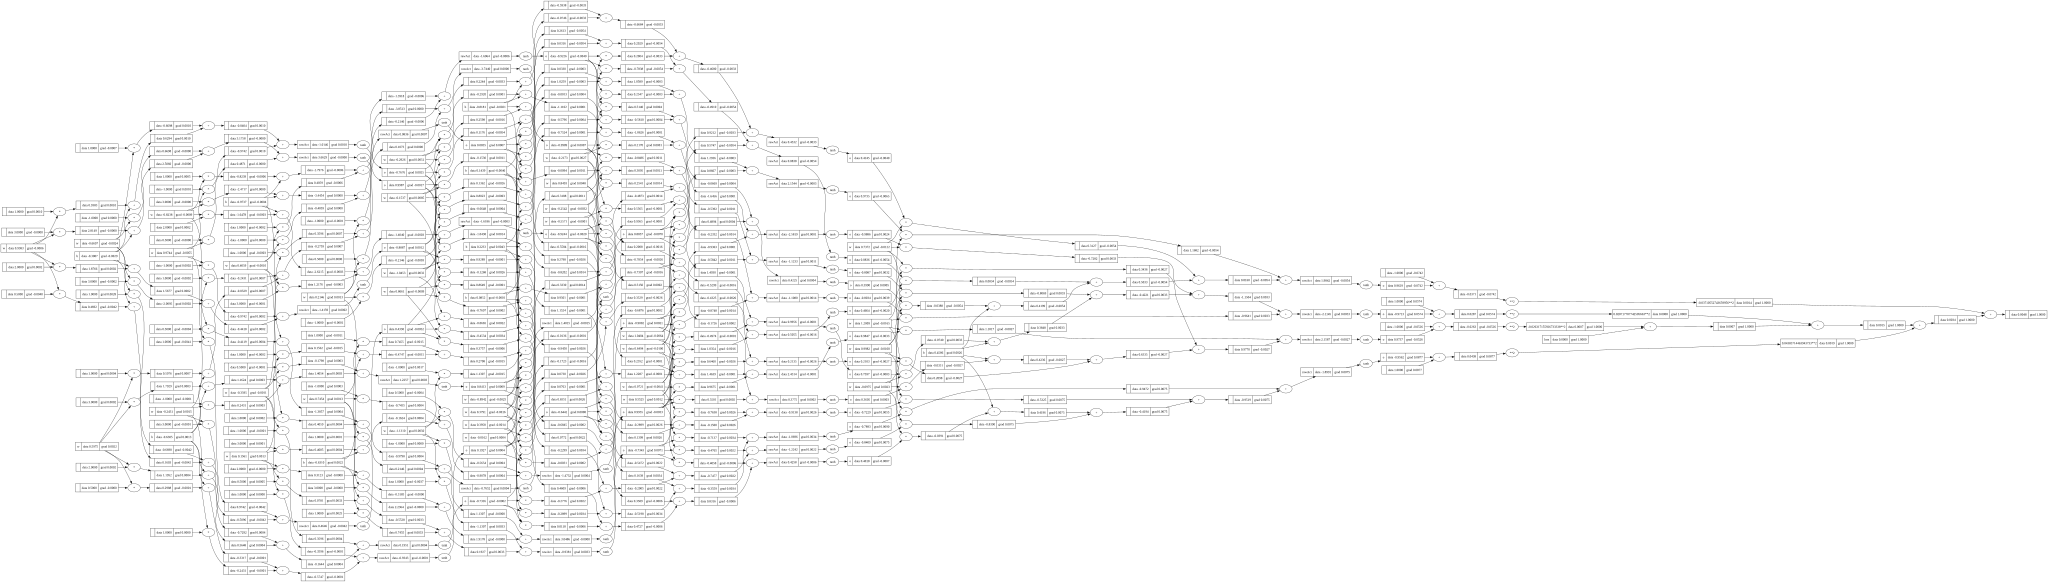

In [250]:
draw_dot(loss)